In [1]:
%%capture
## [TEMPLATE BEGIN]
## おまじない：実行中のノートブック名からOUTPUT_DIRを決めるコード
from pathlib import Path
from IPython import get_ipython; ip = get_ipython()
if '__vsc_ipynb_file__' in ip.user_ns:
    ## VS Codeで実行されている場合
    THIS_NOTEBOOK_PATH = Path(ip.user_ns['__vsc_ipynb_file__'])
else:
    !pip install ipynbname
    import ipynbname; THIS_NOTEBOOK_PATH = Path(ipynbname.path())
    if "%2F" in THIS_NOTEBOOK_PATH.stem:
        ## Google Colabで実行されている場合
        colab_ip = %system hostname -I   # uses colab magic to get list from bash
        colab_ip = colab_ip[0].strip()   # returns "172.28.0.12"
        colab_port = 9000                # could use 6000, 8080, or 9000
        import requests
        filename = requests.get(f"http://{colab_ip}:{colab_port}/api/sessions").json()[0]["name"]
        THIS_NOTEBOOK_PATH = Path(filename)
    else:
        ## それ以外の場合
        THIS_NOTEBOOK_PATH = THIS_NOTEBOOK_PATH

OUTPUT_DIR = Path("figures") / THIS_NOTEBOOK_PATH.stem
## [TEMPLATE END]

In [2]:
print("File output directory:", OUTPUT_DIR)
# Create the output directory if it does not exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

File output directory: figures/_model_introduction


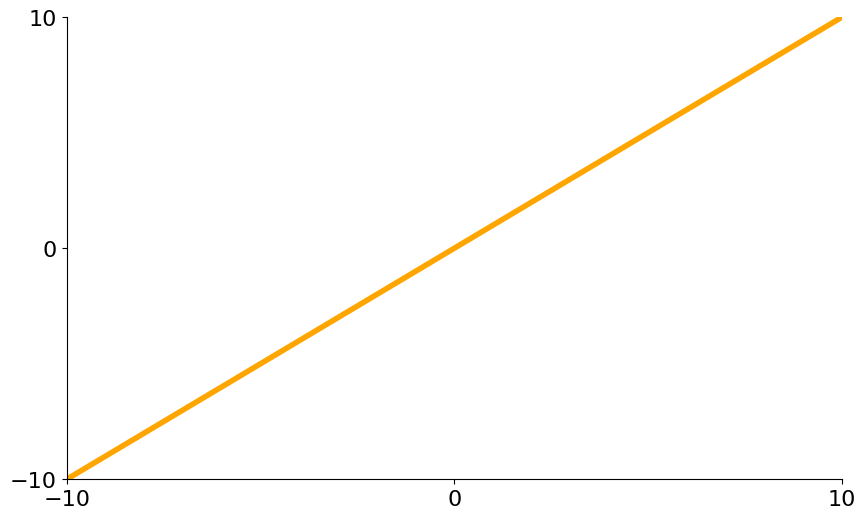

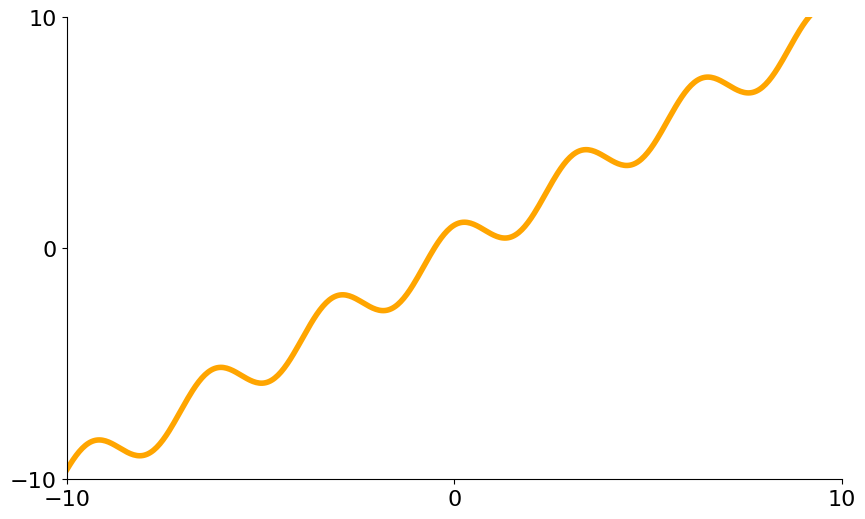

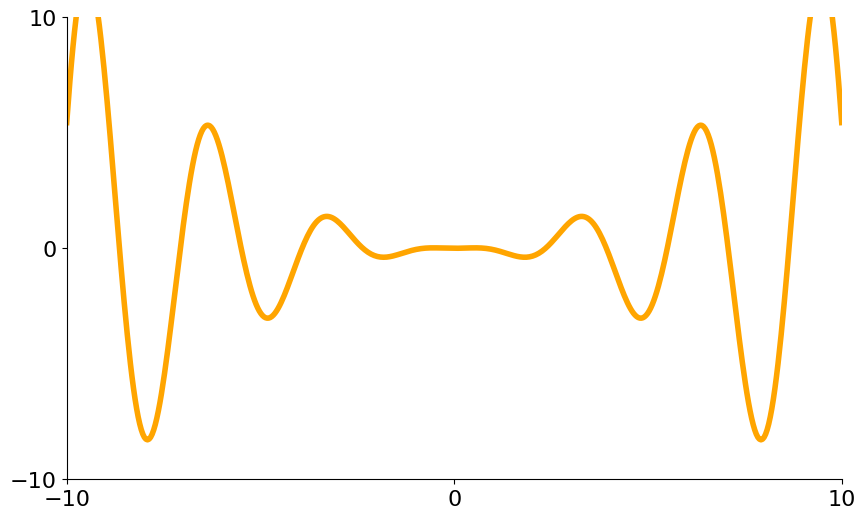

In [108]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math

# Calculate the Taylor coefficients for cos(x) up to a specified order
def taylor_coefficients_cosine(order: int):
    coefficients = [1.]
    for n in range(1, order // 2 + 1):  # Only even powers for cos(x)
        coeff = (-1)**n / math.factorial(2 * n)
        coefficients += [0., coeff]
    return np.array(coefficients)

# Define the polynomial function
def poly_function(theta, x):
    degree = len(theta) - 1
    return sum(theta[i] * x**i for i in range(degree + 1))

# Set up parameters for the polynomials
np.random.seed(42)

# Fixed set of parameters for each function
theta_smooth = np.hstack(([0, .5], np.zeros(101 - 2)))      # Very smooth function: slowly decaying parameters
_cosine_coeff = taylor_coefficients_cosine(100)
theta_medium = _cosine_coeff + theta_smooth                 # Adequately smooth: moderate oscillation
theta_rough = np.hstack(([0, 0], _cosine_coeff[:-2])) / 30   # Rough function: randomly fluctuating parameters

# Define the range for x-axis
x = np.linspace(-10, 10, 500)

# Compute the values of the polynomial for each function, scaling x by 2
y_smooth = poly_function(theta_smooth, x * 2)
y_medium = poly_function(theta_medium, x * 2)
y_rough = poly_function(theta_rough, x * 2)

# Plot and save each figure separately with orange curves, no top and right borders, and keeping ticks only at [-10, 0, 10]
output_dir = OUTPUT_DIR
orange_color = "#FFA500"  # Orange color from the palette

# Smooth function plot
plt.figure(figsize=(10, 6))
plt.plot(x, y_smooth, color=orange_color, linewidth=4)  # Orange color and increased linewidth for bolder curves
plt.xlim([-10, 10])
plt.ylim([-10, 10])
plt.xticks([-10, 0, 10], fontsize=16)  # Keep ticks only at -10, 0, 10
plt.yticks([-10, 0, 10], fontsize=16)  # Keep ticks only at -10, 0, 10

# Remove the top and right spines (borders)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig(output_dir / "smooth_function.png", bbox_inches='tight', pad_inches=0)
plt.show()

# Medium function plot
plt.figure(figsize=(10, 6))
plt.plot(x, y_medium, color=orange_color, linewidth=4)  # Orange color and increased linewidth for bolder curves
plt.xlim([-10, 10])
plt.ylim([-10, 10])
plt.xticks([-10, 0, 10], fontsize=16)  # Keep ticks only at -10, 0, 10
plt.yticks([-10, 0, 10], fontsize=16)  # Keep ticks only at -10, 0, 10

# Remove the top and right spines (borders)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig(output_dir / "medium_function.png", bbox_inches='tight', pad_inches=0)
plt.show()

# Rough function plot
plt.figure(figsize=(10, 6))
plt.plot(x, y_rough, color=orange_color, linewidth=4)  # Orange color and increased linewidth for bolder curves
plt.xlim([-10, 10])
plt.ylim([-10, 10])
plt.xticks([-10, 0, 10], fontsize=16)  # Keep ticks only at -10, 0, 10
plt.yticks([-10, 0, 10], fontsize=16)  # Keep ticks only at -10, 0, 10

# Remove the top and right spines (borders)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig(output_dir / "rough_function.png", bbox_inches='tight', pad_inches=0)
plt.show()